# Task 02 – Used Car Price Prediction



In [1]:
# ===== Step 0: Upload dataset (Colab) =====

import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

CSV_PATH = '/content/dataset-2.csv'
RANDOM_STATE = 42


In [2]:
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)

# target -> numeric
y = pd.to_numeric(df['price'].astype(str).str.replace(r'[\$,]', '', regex=True), errors='coerce')
X = df.drop(columns=['price'])

# 70 / 15 / 15
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=RANDOM_STATE)
print(len(X_train), len(X_val), len(X_test))


Shape: (3207, 12)
2244 481 482


## Step 2: EDA (train set only)


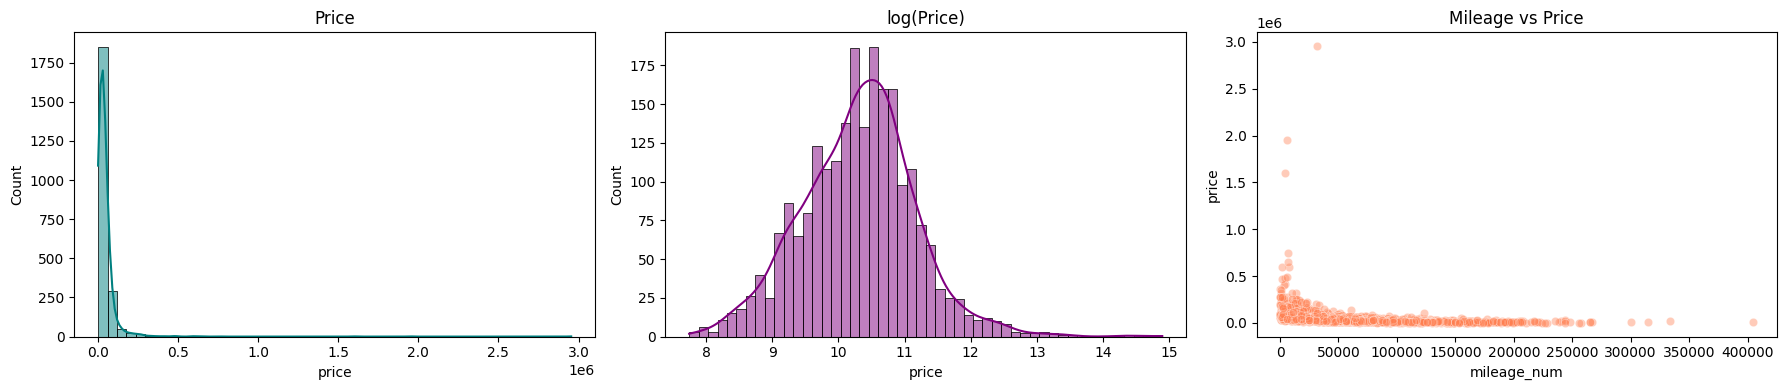

fuel_type       91
accident        66
clean_title    336
dtype: int64
count    2.244000e+03
mean     4.575939e+04
std      9.531089e+04
min      2.300000e+03
25%      1.700000e+04
50%      3.067450e+04
75%      4.999575e+04
max      2.954083e+06
Name: price, dtype: float64


In [3]:
train_viz = X_train.copy(); train_viz['price'] = y_train
train_viz['mileage_num'] = pd.to_numeric(train_viz['milage'].astype(str).str.replace(r'[^\d]', '', regex=True), errors='coerce')

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(train_viz['price'], bins=50, kde=True, color='teal', ax=ax[0]); ax[0].set_title('Price')
sns.histplot(np.log1p(train_viz['price']), bins=50, kde=True, color='purple', ax=ax[1]); ax[1].set_title('log(Price)')
sns.scatterplot(x='mileage_num', y='price', data=train_viz, alpha=.4, color='coral', ax=ax[2]); ax[2].set_title('Mileage vs Price')
plt.tight_layout(); plt.show()
print(train_viz.isnull().sum()[lambda s: s > 0])
print(train_viz['price'].describe())


## Step 3: Feature function (NO row dropping, NO price use)



In [6]:
import re

def clean_and_engineer(X):
    """Same number of rows in/out. Uses only feature columns (never price)."""
    X = X.copy()

    # mileage
    X['mileage'] = pd.to_numeric(X['milage'].astype(str).str.replace(r'[^\d]', '', regex=True), errors='coerce')
    X = X.drop(columns=['milage'])

    # engine text -> numeric
    eng = X['engine'].astype(str)
    X['hp']        = pd.to_numeric(eng.str.extract(r'(\d+\.?\d*)\s*HP', flags=re.I)[0], errors='coerce')
    X['liters']    = pd.to_numeric(eng.str.extract(r'(\d+\.?\d*)\s*L(?:iter)?\b', flags=re.I)[0], errors='coerce')
    X['cylinders'] = pd.to_numeric(eng.str.extract(r'(\d+)\s*Cylinder', flags=re.I)[0], errors='coerce')
    cyl_alt = pd.to_numeric(eng.str.extract(r'\b[VI](\d{1,2})\b', flags=re.I)[0], errors='coerce')   # V8, V6 ...
    X['cylinders'] = X['cylinders'].fillna(cyl_alt)
    X['is_turbo']  = eng.str.contains('turbo', case=False).astype(int)
    X['is_electric'] = eng.str.contains('electric', case=False).astype(int)

    # age & usage
    X['car_age'] = 2025 - X['model_year']
    X['miles_per_year'] = X['mileage'] / X['car_age'].clip(lower=1)

    # transmission simplify
    t = X['transmission'].astype(str).str.lower()
    X['trans_type'] = np.select(
        [t.str.contains('cvt'), t.str.contains('m/t|manual'), t.str.contains('a/t|auto|dual|dct')],
        ['CVT', 'Manual', 'Automatic'], default='Other')

    # accident / clean title
    X['accident'] = X['accident'].map(lambda v: np.nan if pd.isna(v) else int('At least 1' in str(v)))
    X['clean_title'] = X['clean_title'].map(lambda v: 1 if str(v).strip().lower() == 'yes' else 0)

    # fill text cols (constant label, no leakage)
    for c in ['fuel_type', 'brand', 'model', 'ext_col', 'int_col']:
        X[c] = X[c].fillna('Unknown').astype(str)

    return X.drop(columns=['engine', 'transmission'])

def remove_bad_training_rows(X_train, y_train):
    """Train split ONLY: duplicates + extreme price outliers."""
    tmp = X_train.copy(); tmp['price'] = y_train
    tmp = tmp.drop_duplicates()
    tmp = tmp[(tmp['price'] >= 1000) & (tmp['price'] <= 500000)]
    return tmp.drop(columns=['price']), tmp['price']

X_train, y_train = remove_bad_training_rows(X_train, y_train)

print("NaN in y_train:", y_train.isna().sum())

F_train, F_val, F_test = (clean_and_engineer(d) for d in (X_train, X_val, X_test))
F_train.head()


NaN in y_train: 0


,brand,model,model_year,fuel_type,ext_col,int_col,accident,clean_title,mileage,hp,liters,cylinders,is_turbo,is_electric,car_age,miles_per_year,trans_type
1508,Porsche,Cayenne Turbo,2009,Gasoline,Black,Beige,1.0,1,41965,500.0,4.8,8.0,0,0,16,2622.8125,Automatic
1944,Chevrolet,Suburban Premier,2017,Gasoline,White,Beige,1.0,1,166549,355.0,5.3,8.0,0,0,8,20818.6250,Automatic
3156,Nissan,370Z Touring,2009,Gasoline,Silver,Orange,0.0,1,37500,332.0,3.7,6.0,0,0,16,2343.7500,Manual
2644,BMW,X5 xDrive35i,2017,Gasoline,Gray,Black,0.0,1,72700,300.0,3.0,6.0,0,0,8,9087.5000,Automatic
1203,Land,Rover Range Rover P525 Westminster,2021,Gasoline,Santorini Black Metallic,Ebony,0.0,0,17945,NaN,5.0,8.0,0,0,4,4486.2500,Automatic


## Step 4: Pipeline (encode + impute inside Pipeline, log-target)


In [7]:
numeric_features = ['model_year', 'mileage', 'hp', 'liters', 'cylinders', 'car_age', 'miles_per_year',
                    'is_turbo', 'is_electric', 'accident', 'clean_title']
categorical_features = ['brand', 'model', 'fuel_type', 'ext_col', 'int_col', 'trans_type']

def make_pipeline(regressor, scale=False):
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale: num_steps.append(('scaler', StandardScaler()))
    pre = ColumnTransformer([
        ('num', Pipeline(num_steps), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1,
                                   min_frequency=3, encoded_missing_value=-1))]), categorical_features)
    ])
    # log1p target -> predictions auto converted back to dollars via expm1
    return TransformedTargetRegressor(
        regressor=Pipeline([('prep', pre), ('reg', regressor)]),
        func=np.log1p, inverse_func=np.expm1)

def evaluate(model, X, y, name):
    p = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, p)); mae = mean_absolute_error(y, p); r2 = r2_score(y, p)
    print(f'{name:<11} RMSE ${rmse:>10,.0f} | MAE ${mae:>9,.0f} | R2 {r2:.4f}')
    return mae

candidates = {
  'RandomForest': make_pipeline(RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)),
  'HistGB':       make_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
}
for n, m in candidates.items():
    m.fit(F_train, y_train); evaluate(m, F_val, y_val, n + ' (val)')


RandomForest (val) RMSE $    31,361 | MAE $   11,402 | R2 0.5736
HistGB (val) RMSE $    30,240 | MAE $   10,283 | R2 0.6036


## Step 5: Hyperparameter tuning (MAE, cross-validation on train)


In [10]:
# HistGB categorical-as-ordinal: tuning
base = make_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE))
param_dist = {
    'regressor__reg__learning_rate':    [0.03, 0.05, 0.08, 0.1],
    'regressor__reg__max_iter':         [200, 400, 600],
    'regressor__reg__max_depth':        [None, 6, 10],
    'regressor__reg__max_leaf_nodes':   [15, 31, 63],
    'regressor__reg__min_samples_leaf': [10, 20, 40],
    'regressor__reg__l2_regularization':[0, 0.1, 1.0],
}
search = RandomizedSearchCV(base, param_dist, n_iter=25, cv=5,
                            scoring='neg_mean_absolute_error', n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
search.fit(F_train, y_train)
print("Best params:", search.best_params_)
best_model = search.best_estimator_


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'regressor__reg__min_samples_leaf': 10, 'regressor__reg__max_leaf_nodes': 31, 'regressor__reg__max_iter': 400, 'regressor__reg__max_depth': 10, 'regressor__reg__learning_rate': 0.1, 'regressor__reg__l2_regularization': 0}


## Step 6: Final evaluation (Train / Val / Test)


Train       RMSE $     4,096 | MAE $    1,914 | R2 0.9914
Validation  RMSE $    29,599 | MAE $   10,045 | R2 0.6202
Test        RMSE $    33,672 | MAE $   10,989 | R2 0.6305


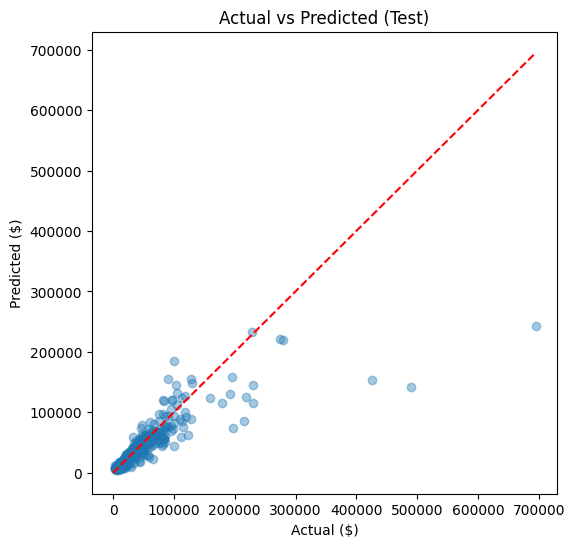

In [12]:
evaluate(best_model, F_train, y_train, 'Train')
evaluate(best_model, F_val,   y_val,   'Validation')
evaluate(best_model, F_test,  y_test,  'Test')

# Actual vs Predicted
p = best_model.predict(F_test)
plt.figure(figsize=(6,6)); plt.scatter(y_test, p, alpha=.4)
lim = [0, max(y_test.max(), p.max())]; plt.plot(lim, lim, 'r--')
plt.xlabel('Actual ($)'); plt.ylabel('Predicted ($)'); plt.title('Actual vs Predicted (Test)'); plt.show()


## Step 7: Required `predict_price()` function



In [13]:
def predict_price(model, input_data):
    """Raw feature DataFrame (same columns as original CSV minus price) -> predicted prices in US dollars."""
    feats = clean_and_engineer(input_data)
    return model.predict(feats)

print("Sample predictions:", np.round(predict_price(best_model, X_test.head(5)), 0))
print("Actual            :", y_test.head(5).values)


Sample predictions: [42226. 76196.  6950. 32516. 16976.]
Actual            : [39857 85000 14000 32063 24000]


In [14]:
# (Optional) save model
import joblib
joblib.dump(best_model, 'car_price_model.pkl')


['car_price_model.pkl']